In [6]:
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd


In [7]:
titanic=sns.load_dataset('titanic')
titanic.head()
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [9]:
features=['pclass','sex','fare','embarked','age']
target=['survived']
from sklearn.impute import SimpleImputer
imp_mean=SimpleImputer(strategy='mean')
titanic[['age']]=imp_mean.fit_transform(titanic[['age']])

imp_freq=SimpleImputer(strategy='most_frequent')
titanic[['embarked']]=imp_freq.fit_transform(titanic[['embarked']])

In [10]:
#encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
titanic['sex']=le.fit_transform(titanic['sex'])
titanic['embarked']=le.fit_transform(titanic['embarked'])

In [11]:
X=titanic[features]
y=titanic[target]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [13]:
#decision tree model
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(X_test)
print('accuracy',accuracy_score(y_test,y_pred))

accuracy 0.7457627118644068


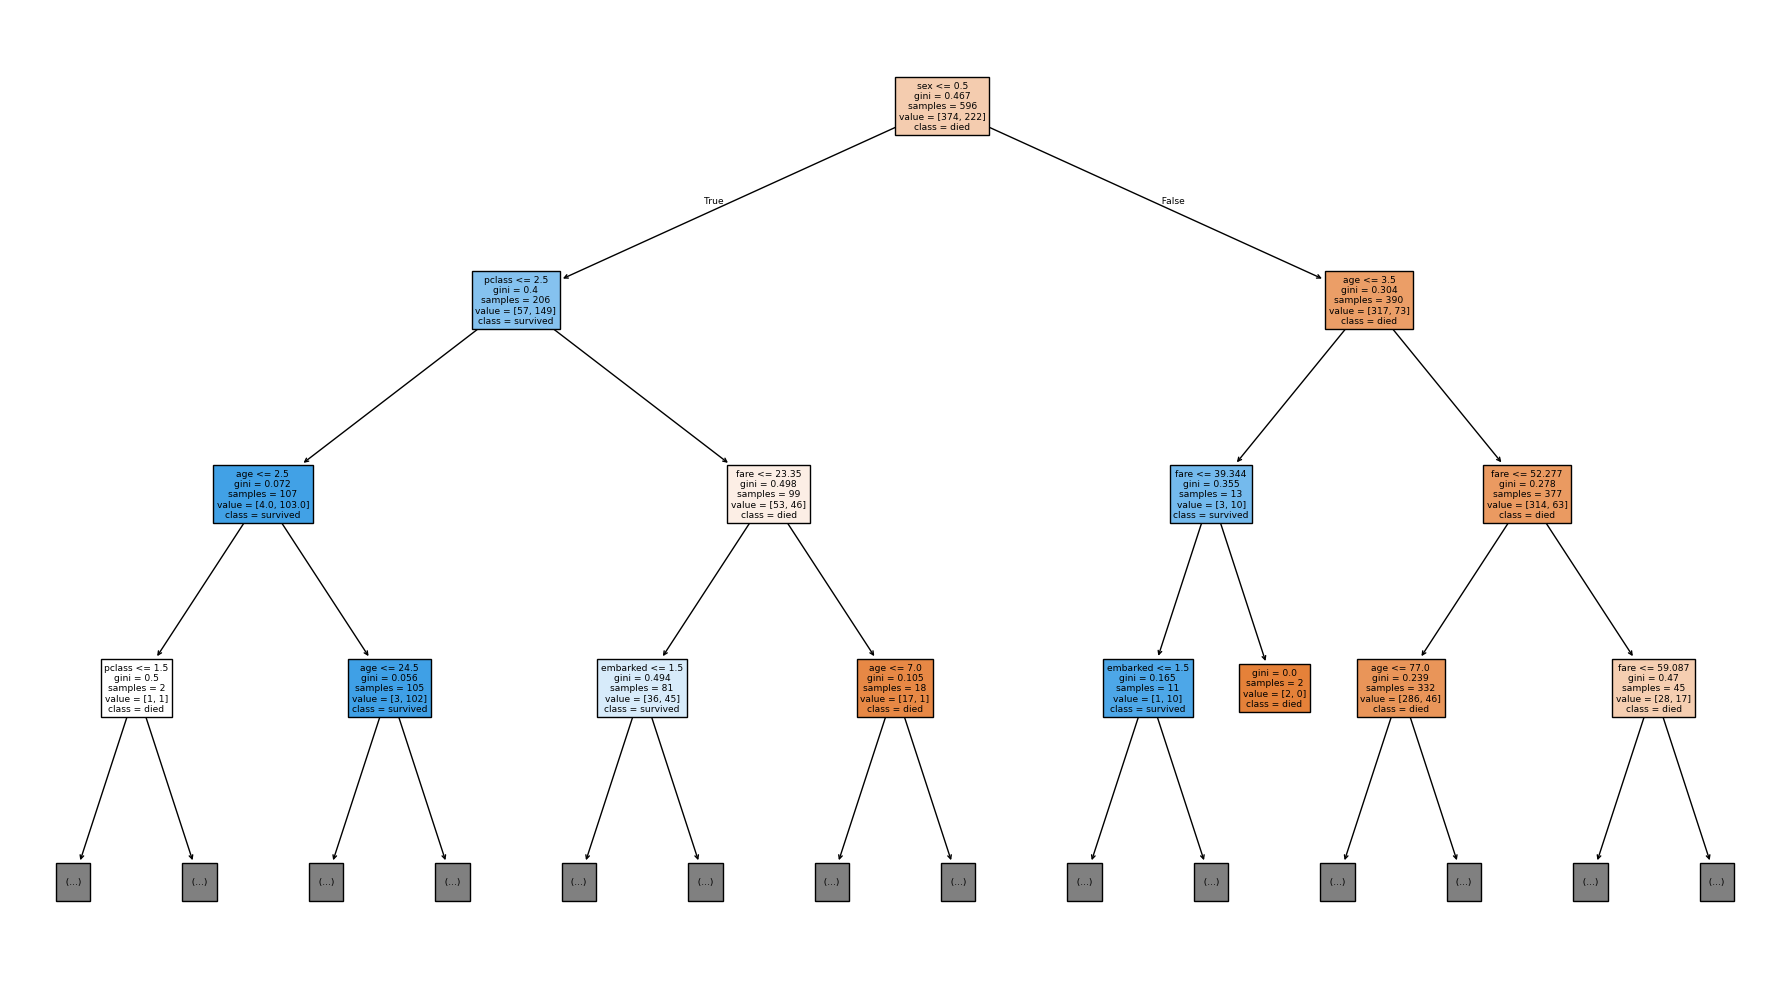

In [16]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['died','survived'],
    filled=True,
    max_depth=3
)
plt.tight_layout()
plt.show()

for depth=2,accuracy=0.7762711864406779
for depth=3,accuracy=0.8169491525423729
for depth=4,accuracy=0.8101694915254237


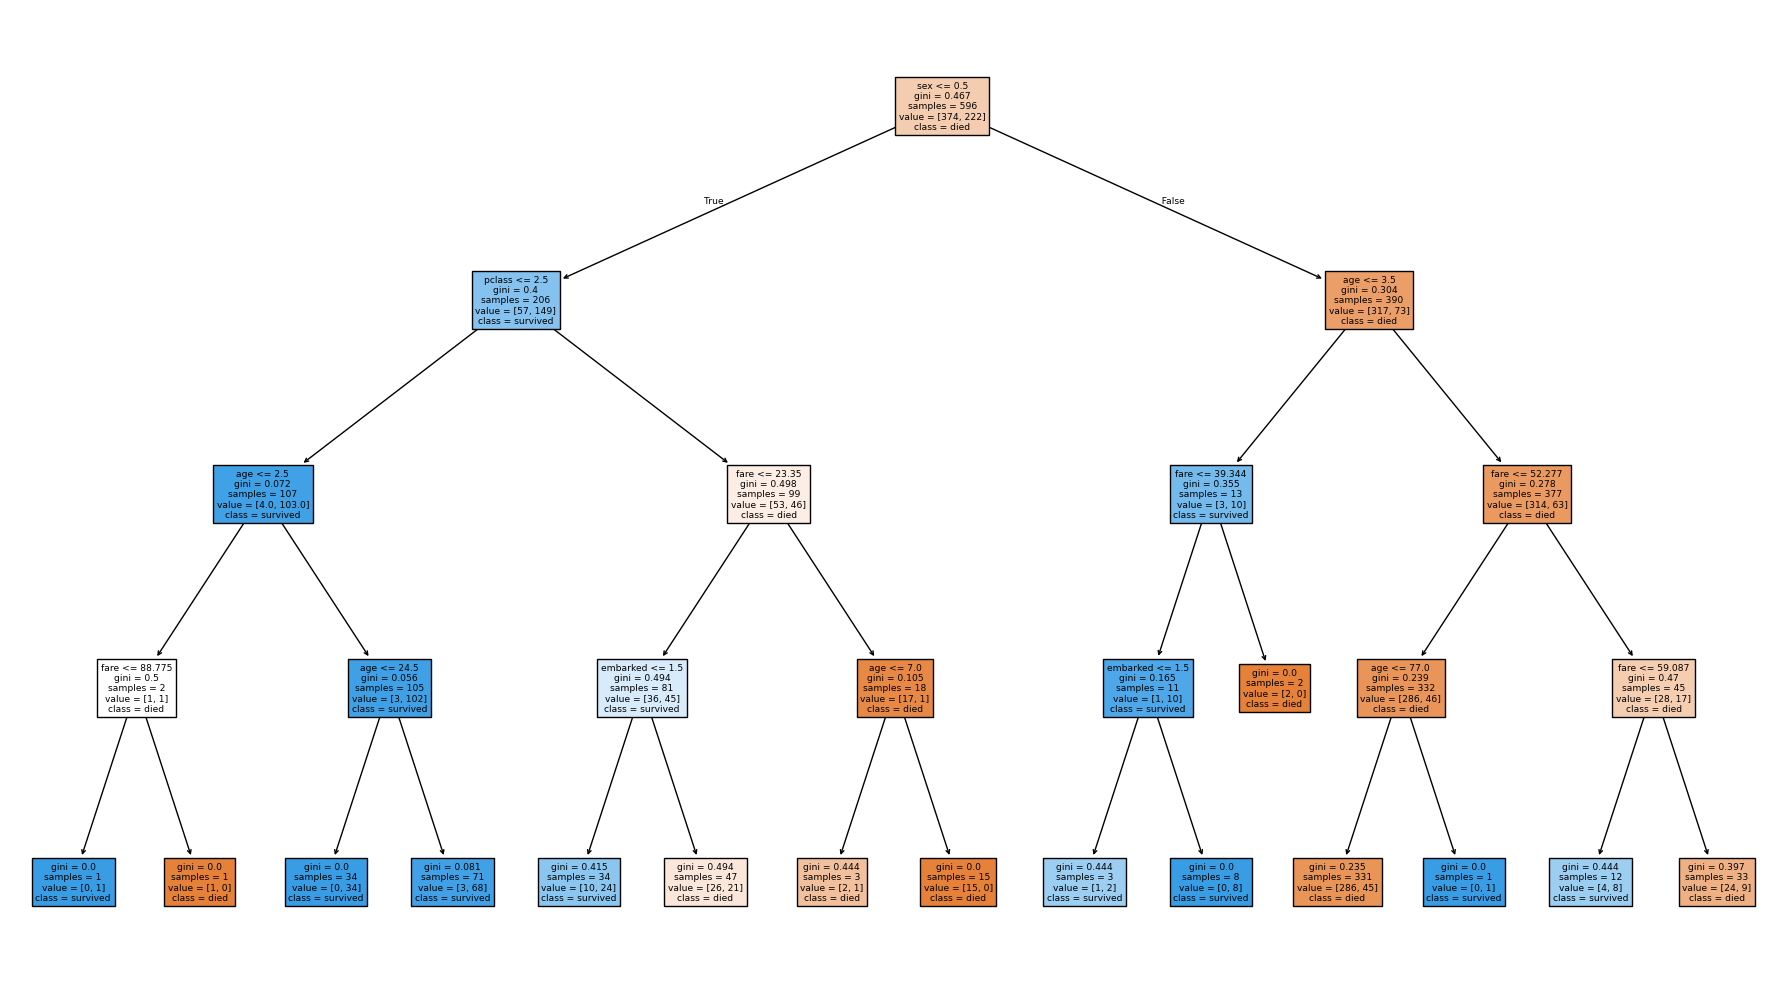

for depth=5,accuracy=0.7762711864406779
for depth=6,accuracy=0.8
for depth=7,accuracy=0.8135593220338984
for depth=8,accuracy=0.8169491525423729
for depth=9,accuracy=0.7932203389830509
for depth=10,accuracy=0.7762711864406779


In [25]:
#pre punning
max_depths=[2,3,4,5,6,7,8,9,10]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train,y_train)
    acc=model.score(X_test,y_test)
    print(f'for depth={depth},accuracy={acc}')

    if depth==4:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=['died','survived'],
            filled=True,
        )
        plt.tight_layout()
        plt.show()

for sample split=10,accuracy=0.8169491525423729


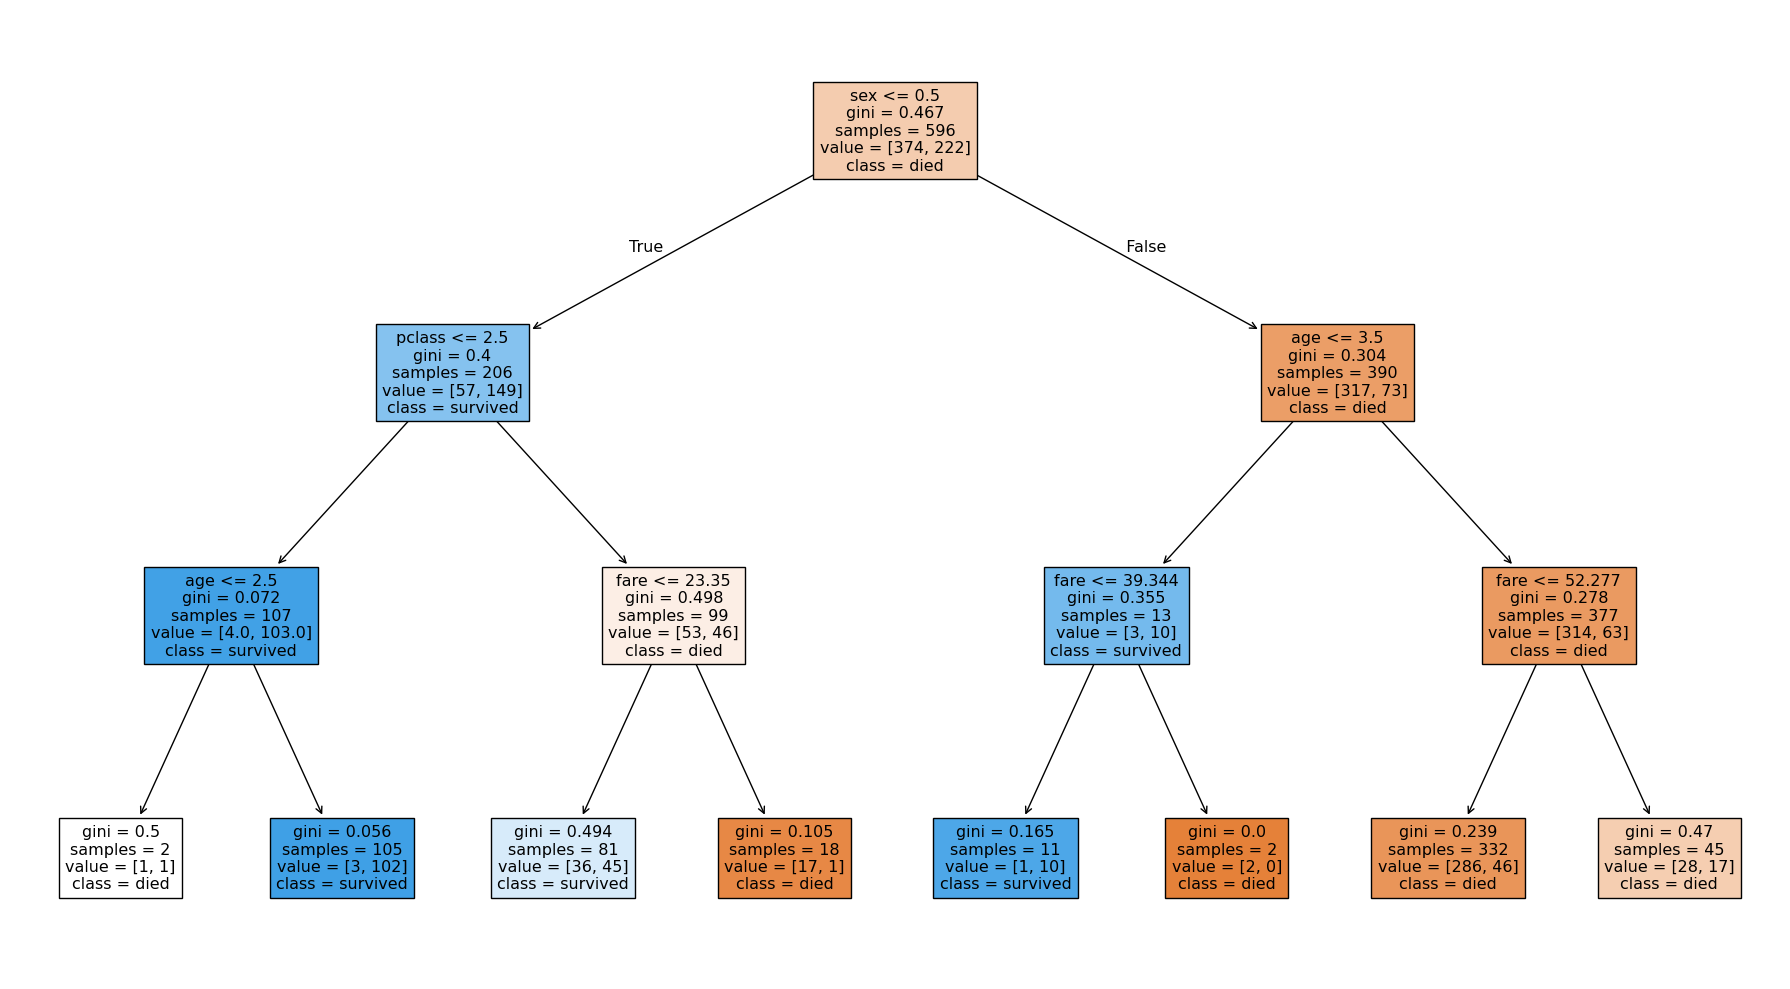

for sample split=15,accuracy=0.8169491525423729
for sample split=20,accuracy=0.8169491525423729
for sample split=25,accuracy=0.8169491525423729
for sample split=30,accuracy=0.8169491525423729


In [26]:
min_samples_splits=[10,15,20,25,30]

for split in min_sample_splits:
    model = DecisionTreeClassifier(max_depth=3,min_samples_split=split)
    model.fit(X_train,y_train)
    acc=model.score(X_test,y_test)
    print(f'for sample split={split},accuracy={acc}')

    if split==10:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=['died','survived'],
            filled=True,
        )
        plt.tight_layout()
        plt.show()

In [28]:
#post prunning
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [29]:
path=full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas=path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 0.00000000e+00 5.99232982e-05
 7.98977309e-05 1.10627627e-04 2.13060616e-04 2.71168056e-04
 4.38529591e-04 5.03355705e-04 5.59284116e-04 5.59284116e-04
 5.59284116e-04 6.71140940e-04 8.94854586e-04 8.94854586e-04
 1.00671141e-03 1.00671141e-03 1.00671141e-03 1.02130143e-03
 1.04399702e-03 1.05969622e-03 1.10187318e-03 1.11856823e-03
 1.12639039e-03 1.21178225e-03 1.25838926e-03 1.29991187e-03
 1.34228188e-03 1.37278829e-03 1.38199916e-03 1.38630758e-03
 1.38745483e-03 1.42617450e-03 1.43980942e-03 1.45550963e-03
 1.47116039e-03 1.52532032e-03 1.57298658e-03 1.58463833e-03
 1.60256860e-03 1.61331957e-03 1.67785235e-03 1.70022371e-03
 1.78970917e-03 1.79769895e-03 1.91754554e-03 1.93053200e-03
 1.94533606e-03 2.05918243e-03 2.09731544e-03 2.26510067e-03
 2.44051251e-03 2.92861501e-03 3.02013423e-03 3.20400359e-03
 4.65286786e-03 4.69329328e-03 4.72945525e-03 5.93149541e-03
 7.61028436e-03 1.23550946e-02 1.52887805e-02 4.27900182e-02
 1.30015678e-01]


In [30]:
#train our model for all alphas,
trees=[]
for alpha in ccp_alphas:
     model = DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
     model.fit(X_train,y_train)
     trees.append((model,alpha))

In [31]:
best_acc=0
best_alpha=0
for model,alpha in trees:
    curr_acc=model.score(X_test,y_test)
    if curr_acc>best_acc:
        best_acc=curr_acc
        best_alpha=alpha

In [33]:
best_acc

0.8169491525423729

In [34]:
best_model=DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


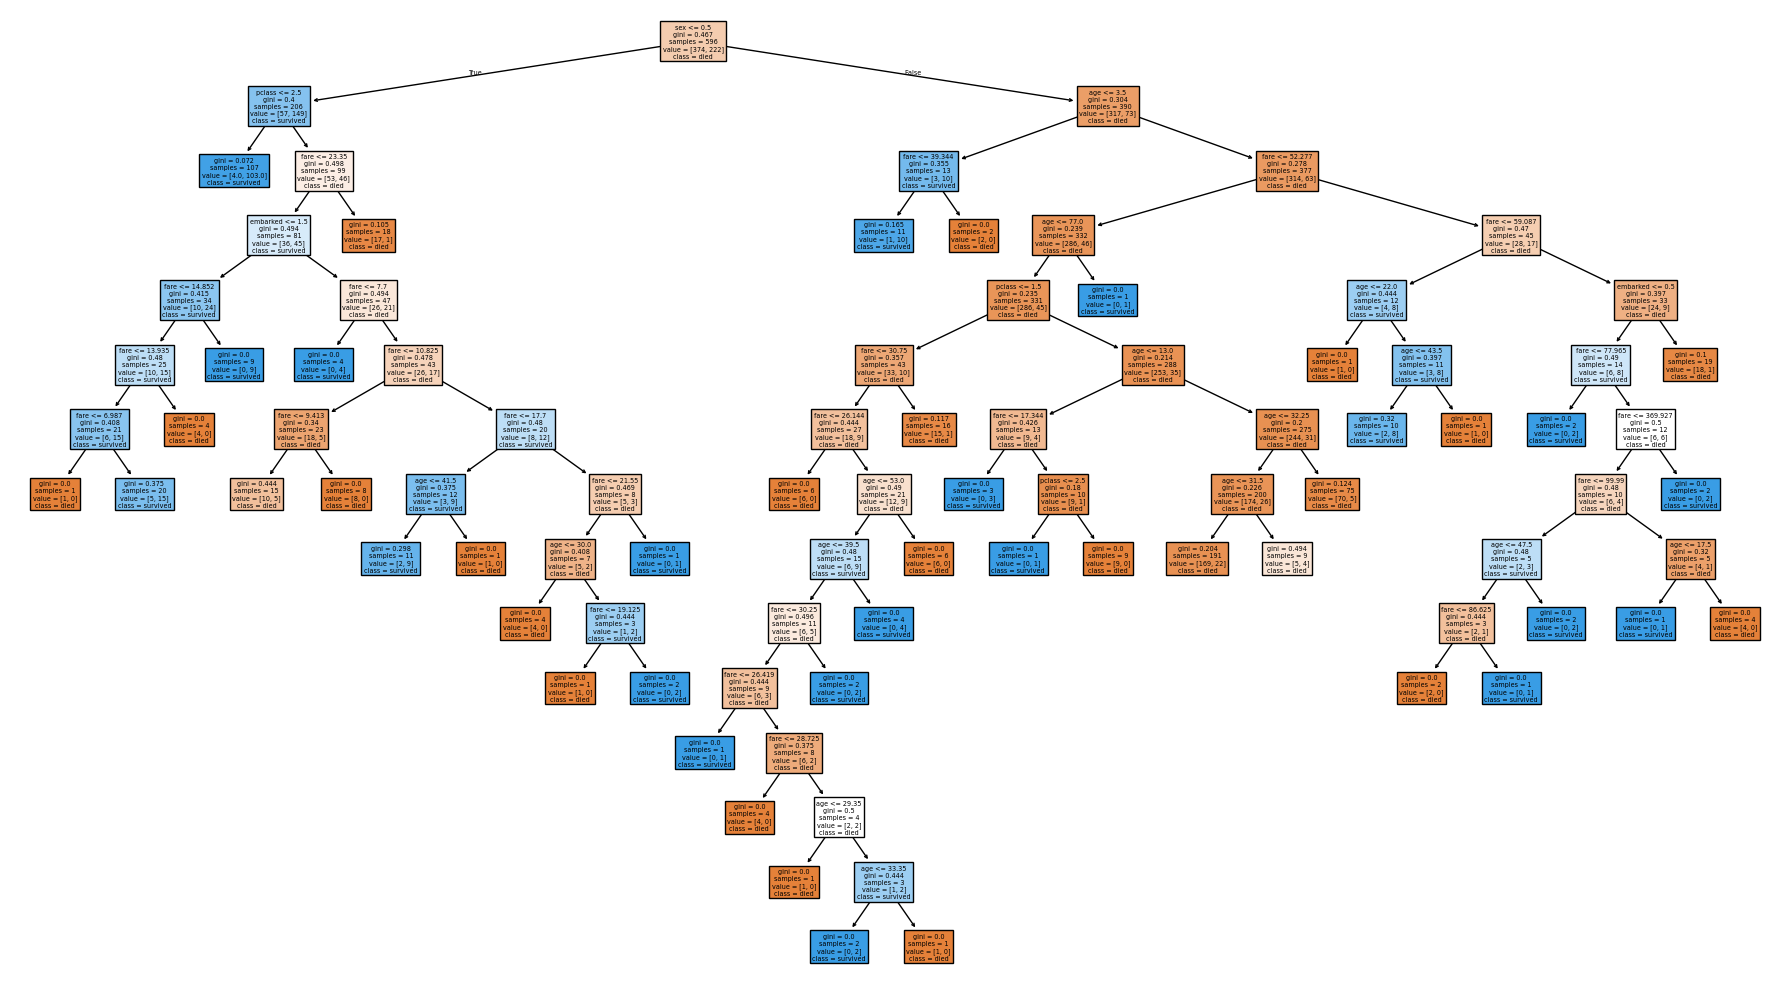

In [35]:
plt.figure(figsize=(18,10))
plot_tree(
      best_model,
     feature_names=X.columns,
     class_names=['died','survived'],
     filled=True,
)
plt.tight_layout()
plt.show()

In [37]:
print(best_model.score(X_test,y_test))

0.8169491525423729
